In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


In [24]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Load Data

In [25]:
transforms=transforms.Compose([transforms.Resize((224,224)),transforms.RandomRotation(10),transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

In [26]:
dataset=datasets.ImageFolder("C:\\Users\\vaisa\\Downloads\\Resources_ModelTraining_CNN\\Download files\\dataset",transform=transforms)
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [27]:
train_dataset,test_dataset=random_split(dataset,[int(0.75*len(dataset)),int(0.25*len(dataset))])


In [28]:
train_loader=DataLoader(train_dataset,shuffle=True,batch_size=32,drop_last=True)
test_loader=DataLoader(test_dataset,shuffle=False,batch_size=32,drop_last=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([224, 224, 3])


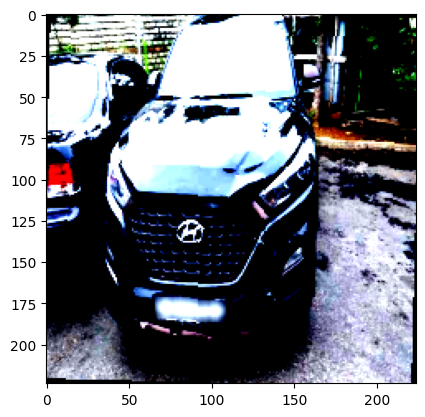

In [29]:
for images,labels in train_loader:
    image=images[0].permute(1,2,0)
    print(image.shape)
    plt.imshow(image)
    break

In [30]:
class CarClassifier(nn.Module):
    def __init__(self,class_count):
        super().__init__()
        self.fc=nn.Sequential(nn.Conv2d(in_channels=3,out_channels=16,stride=1,kernel_size=3,padding=1),nn.BatchNorm2d(16),nn.ReLU(),nn.MaxPool2d(stride=2,kernel_size=2),
                              nn.Conv2d(16,32,padding=1,stride=1,kernel_size=3),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(stride=2,kernel_size=2),
                              nn.Conv2d(32,64,padding=1,stride=1,kernel_size=3),nn.BatchNorm2d(64),nn.ReLU(),
                              nn.MaxPool2d(stride=2,kernel_size=2),nn.Flatten(),nn.Linear(64*28*28,512),nn.ReLU(),
                              nn.Linear(512,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,class_count))
    def forward(self,x):
        x=self.fc(x)
        return x


In [31]:
model=CarClassifier(6).to(device)
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)

In [32]:

def train_model(model,train_loader,optimizer,loss_fn,epochs=5):
    for epoch in range(epochs):
       model.train()
       running_loss=0.0
       correct=0.0
       total=0.0
       for image,label in train_loader:
           image=image.to(device)
           label=label.to(device)
           optimizer.zero_grad()
           output=model(image)
           loss=loss_fn(output,label)
           running_loss+=loss.item()
           loss.backward()
           optimizer.step()
           _, predicted = torch.max(output, 1)
           total += label.size(0)
           correct += (predicted == label).sum().item()

       accuracy = 100 * correct / total
       avg_loss=running_loss/len(train_loader)

       print(f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} "
            f"Train Acc: {accuracy:.2f}%"
        )
    



In [33]:
def test_model(model,test_loader):
    model.eval()
    with torch.no_grad():
        all_predictions=[]
        all_labels=[]
        correct=0.0
        total=0.0
        for image,label in test_loader:
            image=image.to(device)
            label=label.to(device)
            output=model(image)
            _,pred=torch.max(output,1)
            correct+=(pred==label).sum().item()
            total+=label.size(0)
            all_predictions.extend(pred.cpu().numpy())
            all_labels.extend(label.cpu().numpy())
    accuracy=(correct/total)*100
    print(f"Accuracy:{accuracy}%")
    return all_predictions,all_labels
# test_model(model,test_loader)

# Model 2 using EffiecientNet

In [34]:
model_efficient=models.efficientnet_b0(weights='DEFAULT')


class CarClassifierUsingEffiecientNet(nn.Module):
    def __init__(self,num_of_class):
        super().__init__()
        self.network=model_efficient
        for params in self.network.parameters():
            params.requires_grad=False
        in_features=self.network.classifier[1].in_features
        self.network.classifier=nn.Sequential(nn.Dropout(0.5),nn.Linear(in_features,num_of_class))
    def forward(self,x):
        x=self.network(x)
        return x
model_2=CarClassifierUsingEffiecientNet(6).to(device)


In [35]:
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model_2.parameters(),lr=0.005)

In [36]:
# train_model(model_2,train_loader,optimizer,loss_fn) 
# test_model(model_2,test_loader)

In [37]:
models.resnet50(weights='DEFAULT')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

# Model 3 using Resnet

In [38]:


class CarClassifierUsingresNet(nn.Module):
    def __init__(self,num_of_class,dropout=0.4):
        super().__init__()
        self.network=models.resnet50(weights='DEFAULT')
        for params in self.network.parameters():
            params.requires_grad=False
        for param in self.network.layer4.parameters():
                param.requires_grad = True    
        in_features=self.network.fc.in_features
        self.network.fc=nn.Sequential(nn.Dropout(dropout),nn.Linear(in_features,num_of_class))
    def forward(self,x):
        x=self.network(x)
        return x
model_3=CarClassifierUsingresNet(6).to(device)

In [39]:
loss_fn=nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_3.parameters()),
    lr=0.005
)
train_model(model_3,train_loader,optimizer,loss_fn,10) 
predicted,labels =test_model(model_3,test_loader)

Epoch [1/10] Loss: 0.9683 Train Acc: 60.55%
Epoch [2/10] Loss: 0.6133 Train Acc: 75.47%
Epoch [3/10] Loss: 0.4732 Train Acc: 81.54%
Epoch [4/10] Loss: 0.3161 Train Acc: 87.97%
Epoch [5/10] Loss: 0.3338 Train Acc: 87.44%
Epoch [6/10] Loss: 0.2886 Train Acc: 90.15%
Epoch [7/10] Loss: 0.1784 Train Acc: 93.87%
Epoch [8/10] Loss: 0.1634 Train Acc: 94.28%
Epoch [9/10] Loss: 0.1991 Train Acc: 92.51%
Epoch [10/10] Loss: 0.1336 Train Acc: 95.58%
Accuracy:81.80147058823529%


In [40]:


report=classification_report(predicted,labels)
print(report)


              precision    recall  f1-score   support

           0       0.83      0.92      0.87        98
           1       0.82      0.79      0.81       105
           2       0.92      0.86      0.88       139
           3       0.75      0.74      0.75        70
           4       0.56      0.75      0.64        44
           5       0.88      0.77      0.82        88

    accuracy                           0.82       544
   macro avg       0.79      0.81      0.80       544
weighted avg       0.83      0.82      0.82       544



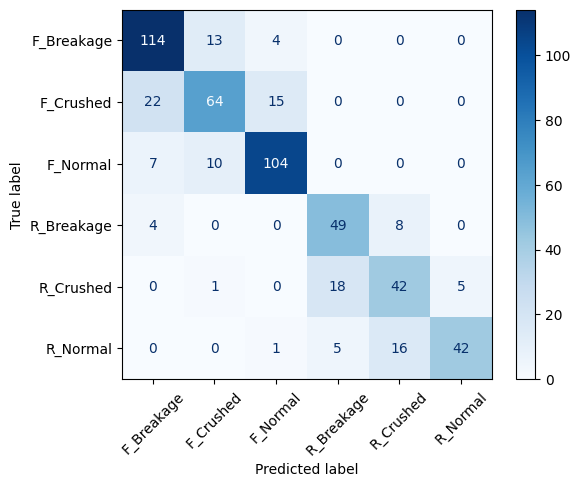

In [19]:
c_matrix=confusion_matrix(labels,predicted,labels=np.arange(len(dataset.classes)))
display=ConfusionMatrixDisplay(confusion_matrix=c_matrix,display_labels=dataset.classes)
display.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.show()


In [20]:
import optuna
def optimizer(trial):
    lr=trial.suggest_float('lr',0.01, 0.07)
    dropout=trial.suggest_float('dropout',0.3,0.7)
    model=CarClassifierUsingresNet(6,dropout=dropout).to(device)
    loss_fn=nn.CrossEntropyLoss()
    optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr)
    epochs=3
    for epoch in range(epochs):
           model.train()
           running_loss=0.0
           correct=0.0
           total=0.0
           for image,label in train_loader:
               image=image.to(device)
               label=label.to(device)
               optimizer.zero_grad()
               output=model(image)
               loss=loss_fn(output,label)
               running_loss+=loss.item()
               loss.backward()
               optimizer.step()
    model.eval()
    with torch.no_grad():
        correct=0.0
        total=0.0
        for image,label in test_loader:
            image=image.to(device)
            label=label.to(device)
            output=model(image)
            _,pred=torch.max(output,1)
            correct+=(pred==label).sum().item()
            total+=label.size(0)
        accuracy=(correct/total)*100
        print(f"Accuracy:{accuracy}%")
    
                    
    return accuracy
        


In [21]:
study=optuna.create_study(direction='maximize')
study.optimize(optimizer,n_trials=15)

[I 2026-08-11 21:08:59,607] A new study created in memory with name: no-name-97938c48-b88b-4776-b2d3-479c7282f725
[I 2026-08-11 21:10:09,257] Trial 0 finished with value: 68.75 and parameters: {'lr': 0.01925143484434133, 'dropout': 0.3522648274165432}. Best is trial 0 with value: 68.75.


Accuracy:68.75%


[I 2026-08-11 21:12:13,048] Trial 1 finished with value: 70.77205882352942 and parameters: {'lr': 0.013626863485413313, 'dropout': 0.6507215182487458}. Best is trial 1 with value: 70.77205882352942.


Accuracy:70.77205882352942%


[I 2026-08-11 21:13:53,557] Trial 2 finished with value: 63.78676470588235 and parameters: {'lr': 0.027108860741014824, 'dropout': 0.3649576373234541}. Best is trial 1 with value: 70.77205882352942.


...

Accuracy:64.15441176470588%


[I 2026-08-11 21:27:11,595] Trial 13 finished with value: 68.01470588235294 and parameters: {'lr': 0.019867257573521327, 'dropout': 0.41380836555741696}. Best is trial 6 with value: 74.08088235294117.


Accuracy:68.01470588235294%


[I 2026-08-11 21:28:22,325] Trial 14 finished with value: 67.09558823529412 and parameters: {'lr': 0.037669573775882696, 'dropout': 0.6004802172434333}. Best is trial 6 with value: 74.08088235294117.


Accuracy:67.09558823529412%


In [41]:
torch.save(model_3.state_dict(), "streamlit-app/model/model.pth")